#**Customer Churn Analysis Using Python**



##**Businesss Understanding**
A telecommunications company is experiencing customer churn.
This project identifies the key factors driving churn and provides actionable recommendations to improve customer retention.

##**Business Question**
Why are customers leaving the company, and what factors contribute most of customer churn?

##**Data Importing**

In [ ]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
plt.style.use("ggplot")

In [ ]:
import pandas as pd

# Load dataset

url = "https://raw.githubusercontent.com/Oluwaseyiajayi/Customer-Churn-Analysis/refs/heads/main/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

# Display first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##**Basic Dataset Exploration**

In [ ]:
# Dataset shape

print(df.shape)

(7043, 21)


In [ ]:
# Column names

print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
# Data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Summary statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Check missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##**Data Cleaning**

In [ ]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove duplicates

df = df.drop_duplicates()

In [ ]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
#Check missing values again
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Fill missing values in TotalCharges with median

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
# Save cleaned data

clean_df = df.copy()

print(clean_df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

##**Exploratory Data Analysis (EDA)**

In [ ]:
#Dataset Overview
clean_df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2281.916928,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2265.270398,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,402.225000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


##**Data Visualization**

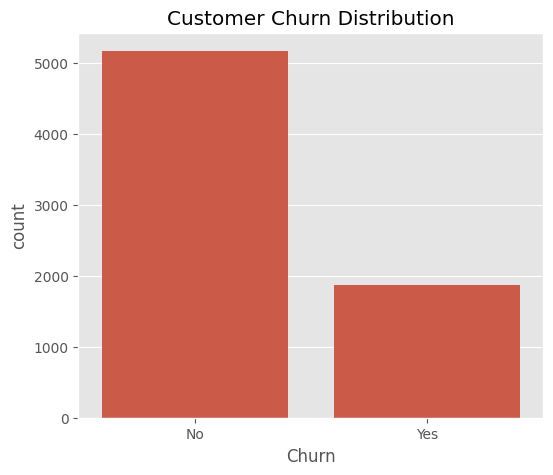

In [ ]:
#Churn Distribution
plt.figure(figsize=(6,5))

sns.countplot(data=clean_df, x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

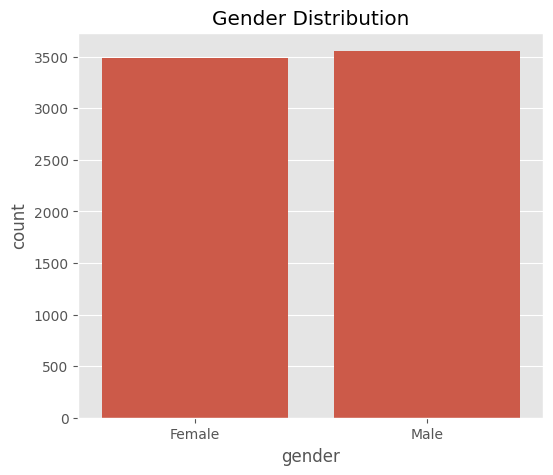

In [ ]:
#Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(data=clean_df, x="gender")

plt.title("Gender Distribution")

plt.show()

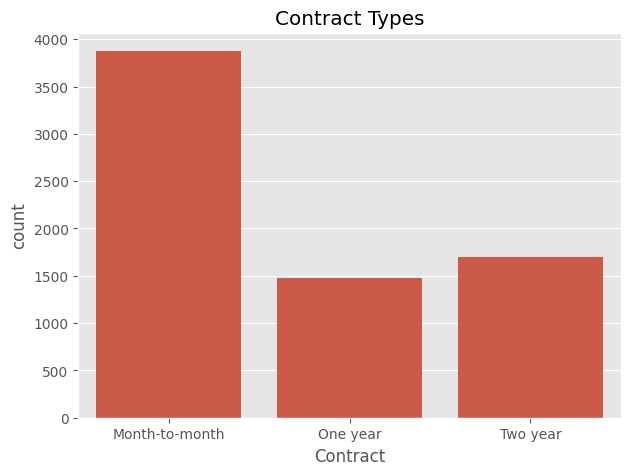

In [ ]:
#Contract Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(data=clean_df, x="Contract")

plt.title("Contract Types")

plt.show()

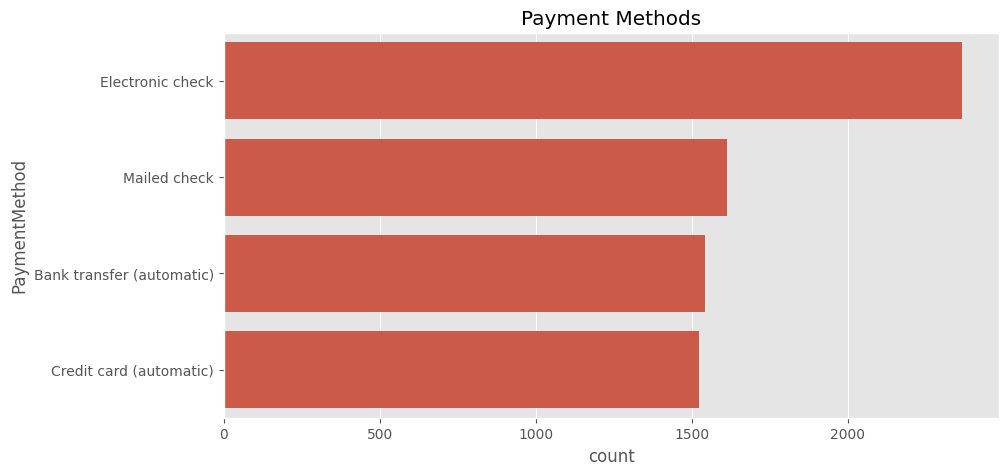

In [ ]:
#Payment Method Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=clean_df,
    y="PaymentMethod",
    order=clean_df["PaymentMethod"].value_counts().index
)

plt.title("Payment Methods")

plt.show()

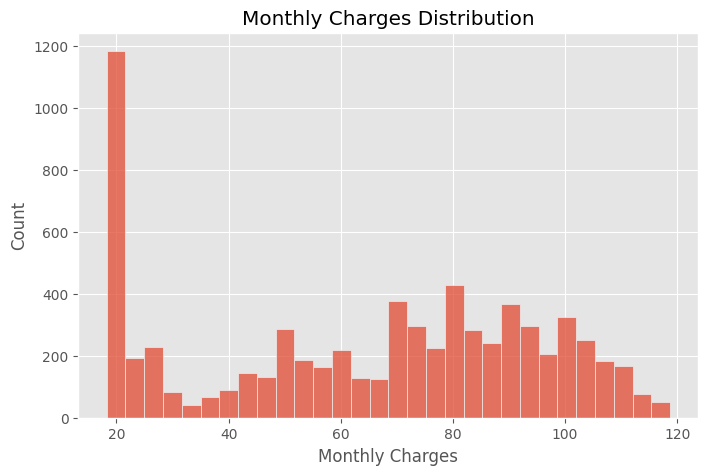

In [ ]:
#Monthly Charges Distribution
plt.figure(figsize=(8,5))

sns.histplot(clean_df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.show()

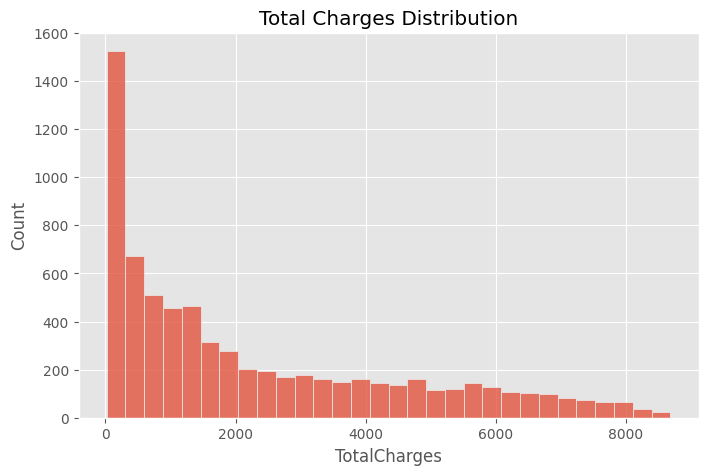

In [ ]:
#Total Charges Distribution
plt.figure(figsize=(8,5))

sns.histplot(clean_df["TotalCharges"], bins=30)

plt.title("Total Charges Distribution")

plt.show()

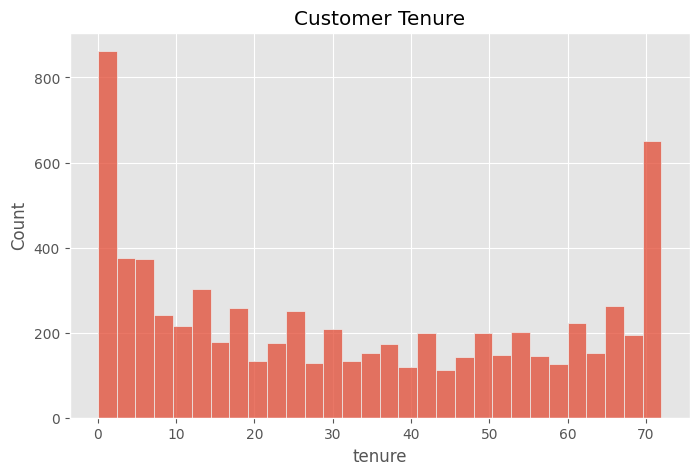

In [ ]:
#Tenure Distribution
plt.figure(figsize=(8,5))

sns.histplot(clean_df["tenure"], bins=30)

plt.title("Customer Tenure")

plt.show()

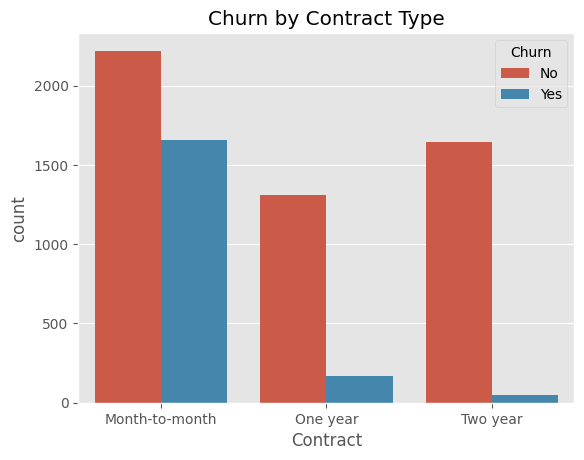

In [ ]:
#Churn vs Contractplt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")

plt.show()

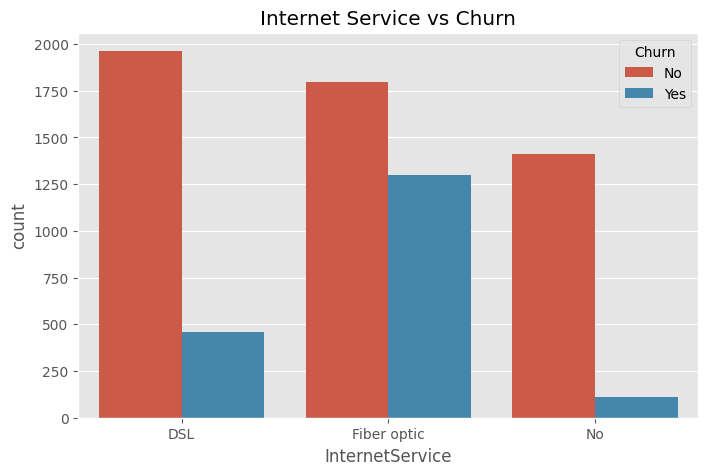

In [ ]:
#Churn vs Internet Service
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

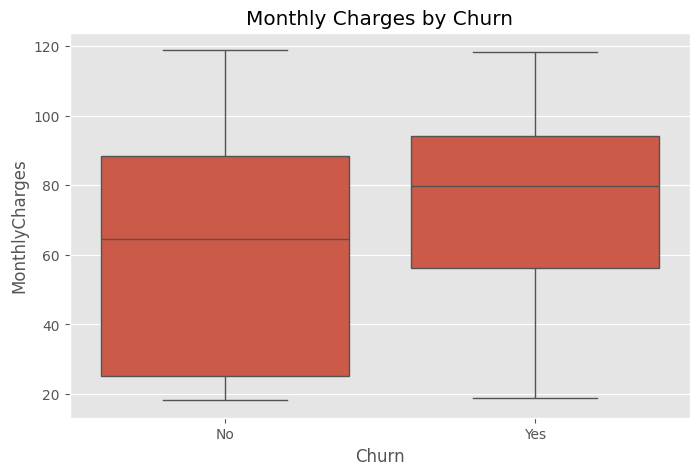

In [ ]:
#Monthly Charges by Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")

plt.show()

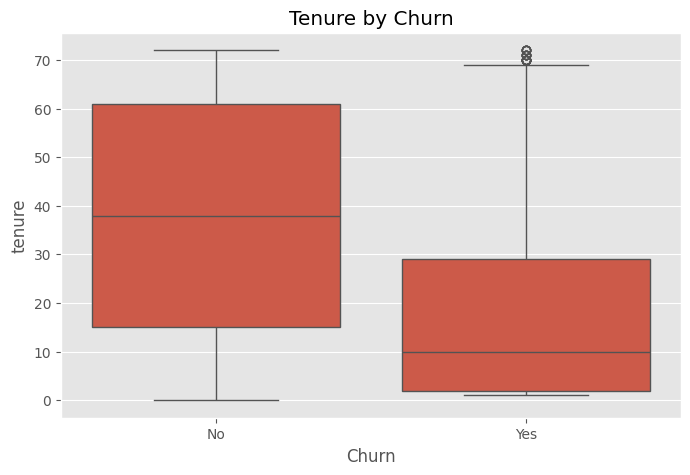

In [ ]:
#Tenure by Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn")

plt.show()

###**Correlation Analysis**

First convert categorical columns.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoded_df = clean_df.copy()

encoder = LabelEncoder()

for col in encoded_df.columns:
    if encoded_df[col].dtype == "object":
        encoded_df[col] = encoder.fit_transform(encoded_df[col])

corr = encoded_df.corr()

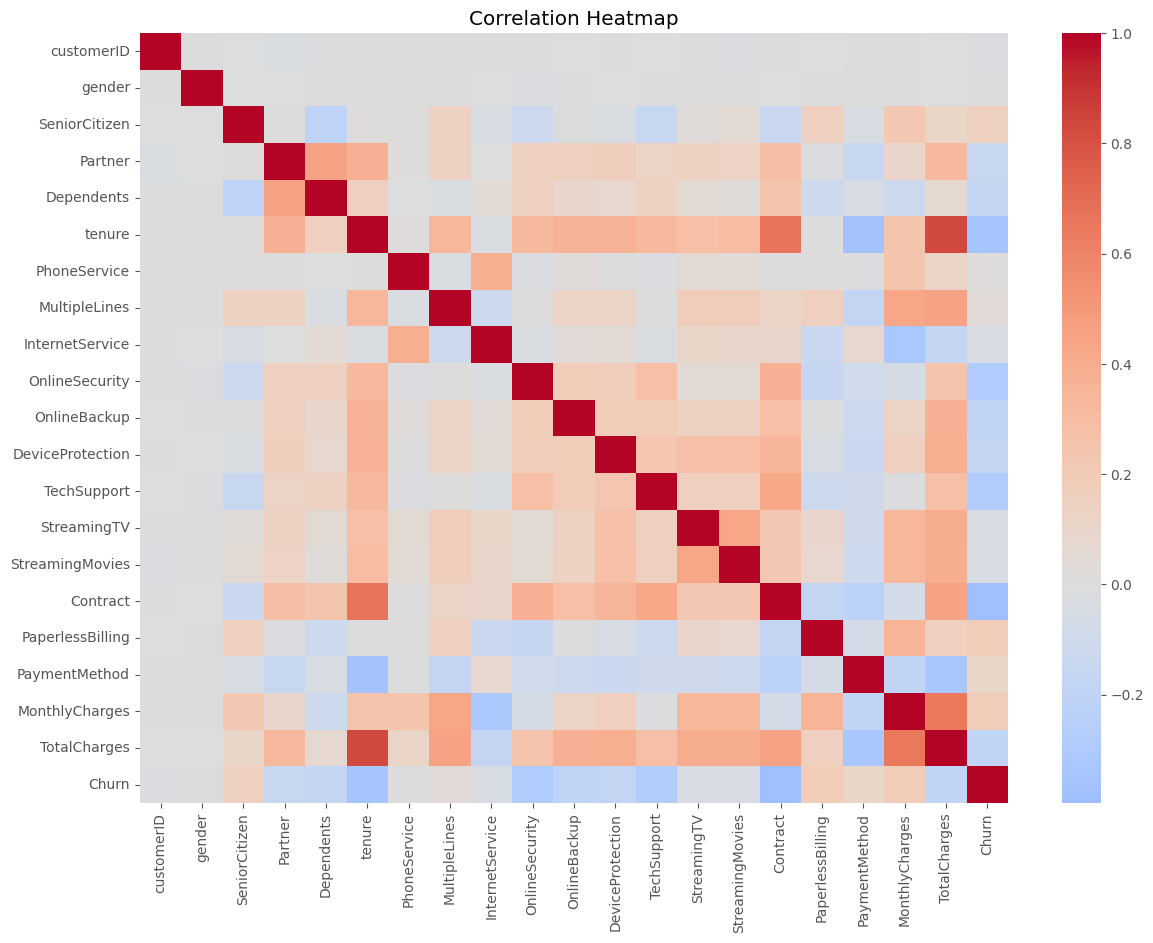

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#Average Monthly Charges by Contract
clean_df.groupby("Contract")["MonthlyCharges"].mean()

,MonthlyCharges
Contract,
Month-to-month,66.398490
One year,65.048608
Two year,60.770413


In [ ]:
#Average Tenure by Churn
clean_df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [ ]:
#Churn Percentage
churn_rate = (
    clean_df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
#Save Cleaned Dataset
clean_df.to_csv(
    "clean_telco_customer_churn.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


##**Insights**

###**Business Question:**
Why are customers leaving the company, and what factors contribute most to customer churn?

**Answer:**
The analysis suggests that customer churn is primarily influenced by contract type, customer tenure, monthly charges, and payment method rather than demographic characteristics such as gender.

**Key Findings and Causes of Churn**

1. Customers on month-to-month contracts are the most likely to churn.

**Evidence:**
The Contract vs Churn count plot shows that customers with month-to-month contracts have substantially higher churn rates than those with one-year or two-year contracts.

**Possible Cause:**
They have no long-term commitment.
They can switch providers easily if they find better prices or services.
They may still be evaluating the service.

**Business Recommendation:**
Offer discounts or loyalty rewards to encourage migration to annual or two-year contracts.

2. New customers are more likely to leave.

**Evidence:**
The Tenure vs Churn box plot shows that churned customers generally have much lower tenure than retained customers.

**Possible Cause:**
Poor onboarding experience.
Expectations not being met early.
Competitors attracting customers with introductory offers.

**Business Recommendation:**
Implement stronger onboarding programs and monitor customers closely during their first 3–6 months.

3. Customers with higher monthly charges are more likely to churn.

**Evidence:**
The MonthlyCharges vs Churn box plot indicates that customers who leave often pay higher monthly fees.

**Possible Cause:**
Customers may perceive the service as too expensive.
They may not feel they are receiving enough value for the price.

**Business Recommendation:**
Review pricing structures and provide personalized discounts or bundled services for high-paying customers.

4. Electronic check users have relatively high churn.

**Evidence:**
The payment method analysis typically shows higher churn among customers using electronic checks compared with automatic payment methods.

**Possible Cause:**
Manual payment processes may be less convenient.
Customers using automatic payments may be more engaged or committed.

**Business Recommendation:**
Encourage customers to adopt automatic bank transfers or credit card payments through incentives.

5. Long-term contracts significantly improve retention.

**Evidence:**
Customers with one-year and two-year contracts exhibit much lower churn rates.

**Possible Cause:**
Long-term agreements increase customer commitment.
Customers on these plans may receive better pricing or benefits.

**Business Recommendation:**
Promote long-term plans with attractive incentives and loyalty rewards.

6. Gender appears to have little effect on churn.

**Evidence:**
The gender distribution shows similar churn patterns between male and female customers.

**Interpretation:**
Marketing and retention campaigns should focus more on behavioral and service-related factors than on gender.

##**Executive Summary**

The analysis indicates that customer churn is driven more by contractual and financial factors than by demographics. Customers who are new to the service, on month-to-month contracts, paying higher monthly charges, and using electronic checks are the most likely to leave. In contrast, customers with longer tenure and long-term contracts tend to remain loyal and contribute more revenue over time.

###**Actionable Recommendations**
+ Convert month-to-month customers to annual or multi-year contracts by offering discounts, bundled services, or loyalty incentives.

+ Strengthen onboarding and engagement during the first 3–6 months, when churn risk is highest.

+ Review pricing strategies for high-bill customers and provide personalized offers to improve perceived value.

+ Encourage automatic payment methods through incentives to reduce friction and increase retention.
